# 🐉 Dragon Fruit Leaf & Fruit Condition Classification
**Author:** Aman Khokhar  
**Course:** 2CEAI603 – Deep Neural Network  
**Models:** Custom CNN · VGG16 · MobileNetV2 · ResNet50 · EfficientNetB0  
**Classes:** Good Leaf · Bad Leaf · Good Fruit · Bad Fruit

##  Step 1 — Check GPU

In [15]:
import tensorflow as tf
print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


##  Step 2 — Install Dependencies

In [16]:
!pip install -q kaggle scikit-learn matplotlib seaborn

##  Step 3 — Download Dataset from Kaggle

>

In [17]:
!kaggle datasets download -d rauf41/dragon-fruit-leaf-and-fruit-dataset
!unzip -q dragon-fruit-leaf-and-fruit-dataset.zip -d dragon_fruit_dataset
!ls dragon_fruit_dataset/

Dataset URL: https://www.kaggle.com/datasets/rauf41/dragon-fruit-leaf-and-fruit-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
dragon-fruit-leaf-and-fruit-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace dragon_fruit_dataset/Augmented/Bad fruit/BGR (1712)_aug_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace dragon_fruit_dataset/Augmented/Bad fruit/BGR (1712)_aug_2.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace dragon_fruit_dataset/Augmented/Bad fruit/BGR (1712)_aug_3.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace dragon_fruit_dataset/Augmented/Bad fruit/BGR (1975)_aug_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace dragon_fruit_dataset/Augmented/Bad fruit/BGR (1975)_aug_2.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: nn
replace dragon_fruit_dataset/Augmented/Bad fruit/BGR (1975)_aug_3.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace dragon_fruit_dataset/Augmented/Bad fruit/BGR (1976)_aug_1.jp

##  Step 4 — Prepare Dataset (Train / Val / Test Split)

In [19]:
import os, shutil, random
from pathlib import Path

# Point specifically to the non-augmented folder
SOURCE_DIR = 'dragon_fruit_dataset/Dragon fruit and leaf'

# Verify path exists
if not os.path.exists(SOURCE_DIR):
    SOURCE_DIR = 'dragon_fruit_dataset'

class_names = [d for d in os.listdir(SOURCE_DIR) if os.path.isdir(os.path.join(SOURCE_DIR, d))]
class_names = sorted(class_names)

DATASET_DIR = 'dataset_small'
random.seed(42)

if os.path.exists(DATASET_DIR): shutil.rmtree(DATASET_DIR)

# Target roughly 500 images total for training across 4 classes (~125 per class)
TRAIN_LIMIT_PER_CLASS = 125

for split in ['train', 'val', 'test']:
    for cls in class_names:
        os.makedirs(os.path.join(DATASET_DIR, split, cls), exist_ok=True)

for cls in class_names:
    src_cls = os.path.join(SOURCE_DIR, cls)
    imgs = [f for f in os.listdir(src_cls) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(imgs)

    # Take a smaller subset for training
    n_train = min(len(imgs), TRAIN_LIMIT_PER_CLASS)
    n_val = int(n_train * 0.2)
    n_test = int(n_train * 0.2)

    split_map = {
        'train': imgs[:n_train],
        'val':   imgs[n_train:n_train + n_val],
        'test':  imgs[n_train + n_val:n_train + n_val + n_test],
    }
    for split, files_list in split_map.items():
        for f in files_list:
            shutil.copy(os.path.join(src_cls, f), os.path.join(DATASET_DIR, split, cls, f))

    print(f'{cls}: train={len(split_map["train"])} val={len(split_map["val"])} test={len(split_map["test"])}')

print('\nReduced Dataset (400-500 train images) split complete!')

Bad fruit: train=125 val=25 test=25
Bad leaf: train=125 val=25 test=25
Good fruit: train=125 val=25 test=25
Good leaf: train=125 val=25 test=25

Reduced Dataset (400-500 train images) split complete!


##  Step 5 — Configuration & Imports

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import VGG16, MobileNetV2, ResNet50, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Flatten

# ── Config ──
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 16 # Smaller batch for smaller dataset
EPOCHS        = 50
PATIENCE      = 5  # Updated as requested
NUM_CLASSES   = 4
LEARNING_RATES = [0.001] # Focus on the most common stable LR

TRAIN_DIR = 'dataset_small/train'
VAL_DIR   = 'dataset_small/val'
TEST_DIR  = 'dataset_small/test'

os.makedirs('results', exist_ok=True)
print(f'Config ready. Using reduced dataset. Patience level: {PATIENCE}')

Config ready. Using reduced dataset. Patience level: 5


##  Step 6 — Explore Dataset

Class                   Train      Val     Test
--------------------------------------------------
Bad fruit                 125       25       25
Bad leaf                  125       25       25
Good fruit                125       25       25
Good leaf                 125       25       25


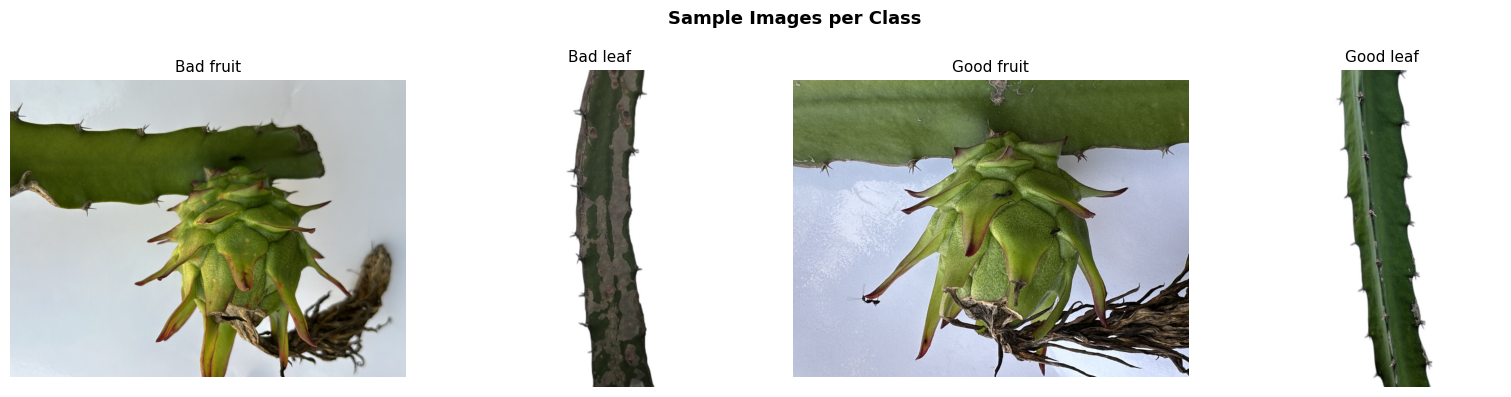

In [21]:
class_names = sorted(os.listdir(TRAIN_DIR))

# Count images per class
print(f'{'Class':<20} {'Train':>8} {'Val':>8} {'Test':>8}')
print('-' * 50)
for cls in class_names:
    tr = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    vl = len(os.listdir(os.path.join(VAL_DIR,   cls)))
    te = len(os.listdir(os.path.join(TEST_DIR,  cls)))
    print(f'{cls:<20} {tr:>8} {vl:>8} {te:>8}')

# Show sample images
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, cls in zip(axes, class_names):
    img_dir  = os.path.join(TRAIN_DIR, cls)
    img_file = os.path.join(img_dir, os.listdir(img_dir)[0])
    img = plt.imread(img_file)
    ax.imshow(img)
    ax.set_title(cls, fontsize=11)
    ax.axis('off')
plt.suptitle('Sample Images per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/sample_images.png', dpi=150)
plt.show()

##  Step 7 — Data Generators (Augmentation)

In [22]:
# train_datagen = ImageDataGenerator(
#     rescale=1./255,
#     rotation_range=30,
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     shear_range=0.2,
#     zoom_range=0.2,
#     horizontal_flip=True,
#     vertical_flip=True,
#     fill_mode='nearest'
# )
# val_test_datagen = ImageDataGenerator(rescale=1./255)

# def get_generators():
#     train_gen = train_datagen.flow_from_directory(
#         TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
#         class_mode='categorical', shuffle=True)
#     val_gen = val_test_datagen.flow_from_directory(
#         VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
#         class_mode='categorical', shuffle=False)
#     test_gen = val_test_datagen.flow_from_directory(
#         TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
#         class_mode='categorical', shuffle=False)
#     return train_gen, val_gen, test_gen

# train_gen, val_gen, test_gen = get_generators()

# # Class weights
# labels = train_gen.classes
# class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
# class_weights = dict(enumerate(class_weights))
# print('Class weights:', class_weights)

In [23]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Data Generator WITHOUT augmentation as requested
train_datagen = ImageDataGenerator(rescale=1./255)
val_test_datagen = ImageDataGenerator(rescale=1./255)

def get_generators():
    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', shuffle=True)
    val_gen = val_test_datagen.flow_from_directory(
        VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', shuffle=False)
    test_gen = val_test_datagen.flow_from_directory(
        TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', shuffle=False)
    return train_gen, val_gen, test_gen

# Initialize generators for the training loop
train_gen, val_gen, test_gen = get_generators()

# Calculate class weights to handle imbalance in the original dataset
labels = train_gen.classes
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = dict(enumerate(class_weights))
print('Class weights:', class_weights)

Found 500 images belonging to 4 classes.
Found 100 images belonging to 4 classes.
Found 100 images belonging to 4 classes.
Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0)}


##  Step 8 — Model Definitions

In [24]:
def build_custom_cnn():
    model = models.Sequential([
        layers.Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=(*IMG_SIZE, 3)),
        layers.BatchNormalization(), layers.MaxPooling2D(2,2),
        layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(), layers.MaxPooling2D(2,2),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(), layers.MaxPooling2D(2,2),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(), layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(512, activation='relu'), layers.Dropout(0.5),
        layers.Dense(256, activation='relu'), layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation='softmax'),
    ], name='CustomCNN')
    return model, None

def build_vgg16():
    base = VGG16(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    base.trainable = False
    model = models.Sequential([
        base, Flatten(),
        Dense(512, activation='relu'), Dropout(0.5),
        Dense(256, activation='relu'), Dropout(0.3),
        Dense(NUM_CLASSES, activation='softmax'),
    ], name='VGG16')
    return model, base

def build_mobilenetv2():
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    base.trainable = False
    model = models.Sequential([
        base, GlobalAveragePooling2D(),
        Dense(256, activation='relu'), Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax'),
    ], name='MobileNetV2')
    return model, base

def build_resnet50():
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    base.trainable = False
    model = models.Sequential([
        base, GlobalAveragePooling2D(),
        Dense(256, activation='relu'), Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax'),
    ], name='ResNet50')
    return model, base

def build_efficientnetb0():
    base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    base.trainable = False
    model = models.Sequential([
        base, GlobalAveragePooling2D(),
        Dense(256, activation='relu'), Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax'),
    ], name='EfficientNetB0')
    return model, base

MODEL_BUILDERS = {
    'CustomCNN':      build_custom_cnn,
    'VGG16':          build_vgg16,
    'MobileNetV2':    build_mobilenetv2,
    'ResNet50':       build_resnet50,
    'EfficientNetB0': build_efficientnetb0,
}
print('All model builders defined.')

All model builders defined.


##  Step 9 — Train All Models × All Learning Rates

Found 500 images belonging to 4 classes.
Found 100 images belonging to 4 classes.
Found 100 images belonging to 4 classes.

  Training CustomCNN  |  LR = 0.001
Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.5100 - loss: 14.5249 - val_accuracy: 0.2700 - val_loss: 12.3380 - learning_rate: 0.0010
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.5320 - loss: 12.9607 - val_accuracy: 0.2500 - val_loss: 24.7987 - learning_rate: 0.0010
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.5840 - loss: 12.6827 - val_accuracy: 0.2500 - val_loss: 40.6682 - learning_rate: 0.0010
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.6540 - loss: 8.9606 - val_accuracy: 0.2500 - val_loss: 33.8439 - learning_rate: 0.0010
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.6680 - loss: 7.5613 - val_accuracy: 0.2500 - val_loss: 17.5236 - learning_rate: 0.0010
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.6500 - loss: 5.900

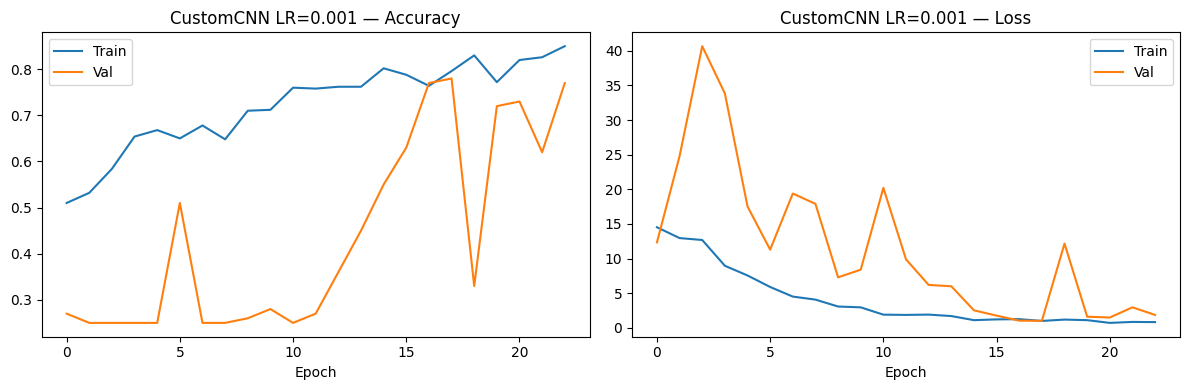


  Accuracy=0.7900  Precision=0.8041  Recall=0.7900  AUC=0.9221


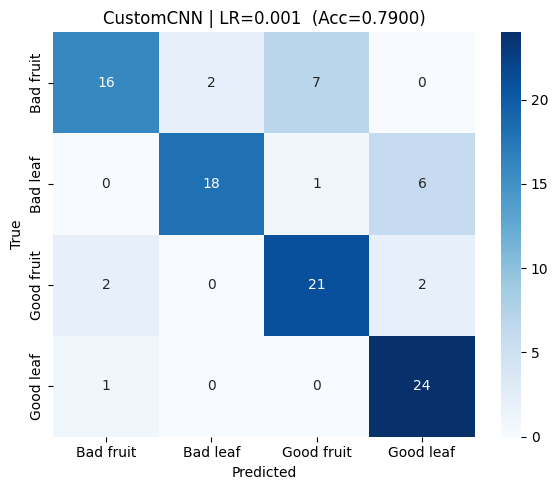

Found 500 images belonging to 4 classes.
Found 100 images belonging to 4 classes.
Found 100 images belonging to 4 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

  Training VGG16  |  LR = 0.001
Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.4560 - loss: 3.4468 - val_accuracy: 0.6900 - val_loss: 0.6103 - learning_rate: 0.0010
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.6020 - loss: 1.2443 - val_accuracy: 0.6700 - val_loss: 0.6178 - learning_rate: 0.0010
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.7220 - loss: 0.7092 - val_accuracy: 0.7500 - val_loss: 0.5207 - learning_rate: 0.0010
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.7360 - loss: 0.6181 - val_accuracy: 0.7800 - val_loss: 0.5512 - learning_rate: 0.0010
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.7600 - loss: 0.5227 - val_accuracy: 0.7200 - val_loss: 0.5968 - learning_rate: 0.0010
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 35s 1

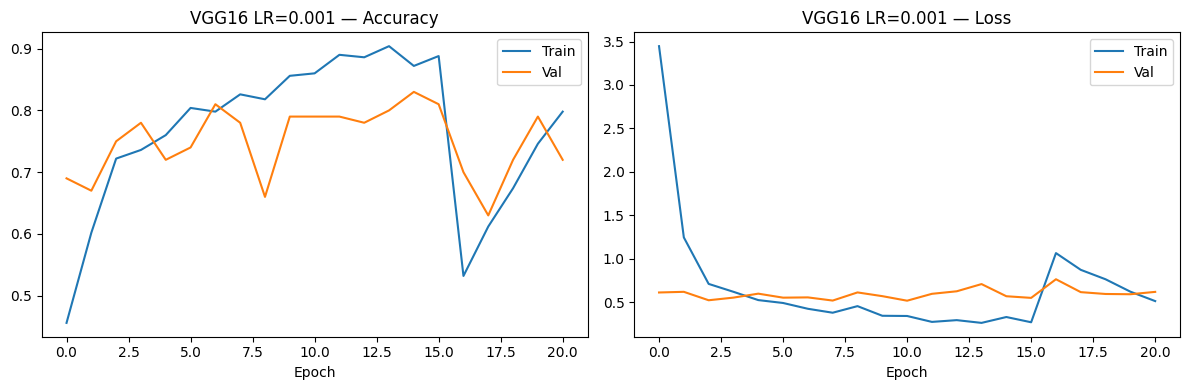


  Accuracy=0.7000  Precision=0.7491  Recall=0.7000  AUC=0.8979


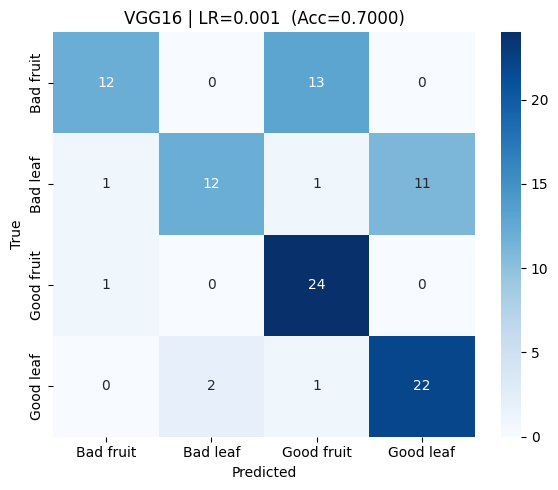

Found 500 images belonging to 4 classes.
Found 100 images belonging to 4 classes.
Found 100 images belonging to 4 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

  Training MobileNetV2  |  LR = 0.001
Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.6900 - loss: 0.8578 - val_accuracy: 0.7600 - val_loss: 0.6418 - learning_rate: 0.0010
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.7980 - loss: 0.4860 - val_accuracy: 0.8500 - val_loss: 0.4118 - learning_rate: 0.0010
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.9040 - loss: 0.2732 - val_accuracy: 0.8300 - val_loss: 0.3945 - learning_rate: 0.0010
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.9020 - loss: 0.2461 - val_accuracy: 0.8000 - val_loss: 0.3966 - learning_rate: 0.0010
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.9100 - loss: 0.2189 - val_accuracy: 0.8400 - val_loss: 0.4243 - learning_rate: 0.0010
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3

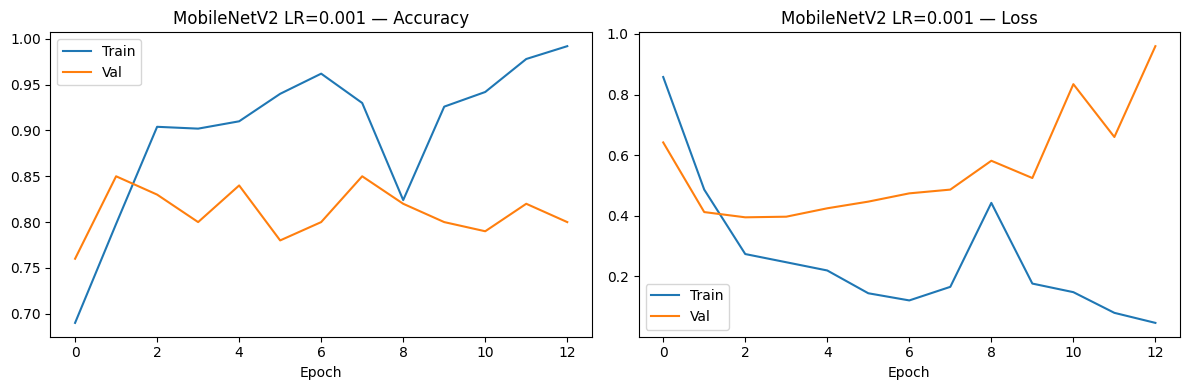


  Accuracy=0.8600  Precision=0.8762  Recall=0.8600  AUC=0.9804


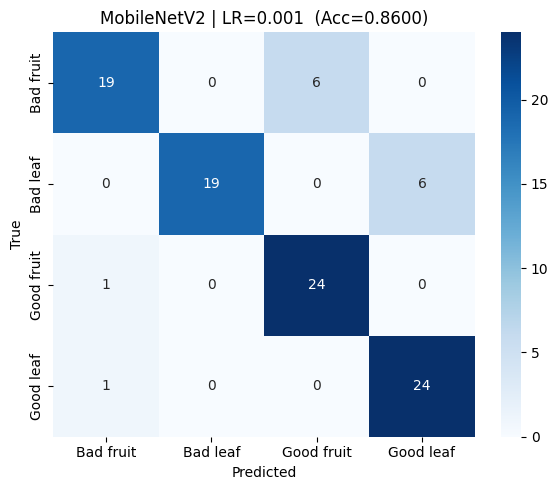

Found 500 images belonging to 4 classes.
Found 100 images belonging to 4 classes.
Found 100 images belonging to 4 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

  Training ResNet50  |  LR = 0.001
Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.3240 - loss: 1.5367 - val_accuracy: 0.4700 - val_loss: 1.1354 - learning_rate: 0.0010
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.4620 - loss: 1.1471 - val_accuracy: 0.5000 - val_loss: 1.0154 - learning_rate: 0.0010
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.4760 - loss: 1.0728 - val_accuracy: 0.5500 - val_loss: 0.9381 - learning_rate: 0.0010
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.4920 - loss: 1.0260 - val_accuracy: 0.5500 - val_loss: 0.9338 - learning_rate: 0.0010
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.4720 - loss: 0.9795 - val_accuracy: 0.6800 - val_loss: 0.8677 - learning_rate: 0.0010
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 35

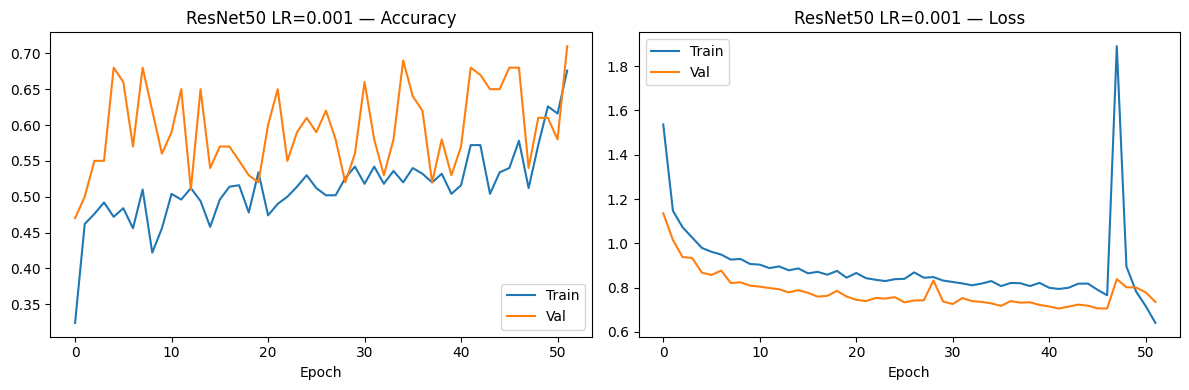


  Accuracy=0.5000  Precision=0.5606  Recall=0.5000  AUC=0.8679


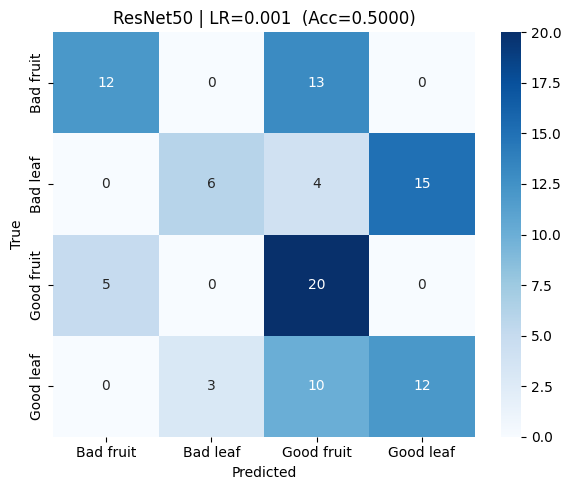

Found 500 images belonging to 4 classes.
Found 100 images belonging to 4 classes.
Found 100 images belonging to 4 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

  Training EfficientNetB0  |  LR = 0.001
Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.2280 - loss: 1.5290 - val_accuracy: 0.2500 - val_loss: 1.3980 - learning_rate: 0.0010
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.2420 - loss: 1.4305 - val_accuracy: 0.2500 - val_loss: 1.3874 - learning_rate: 0.0010
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.2660 - loss: 1.4030 - val_accuracy: 0.2500 - val_loss: 1.3878 - learning_rate: 0.0010
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.2640 - loss: 1.3963 - val_accuracy: 0.2500 - val_loss: 1.3892 - learning_rate: 0.0010
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.2480 - loss: 1.3974 - val_accuracy: 0.2500 - val_loss: 1.3869 - learning_rate: 0.0010
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━

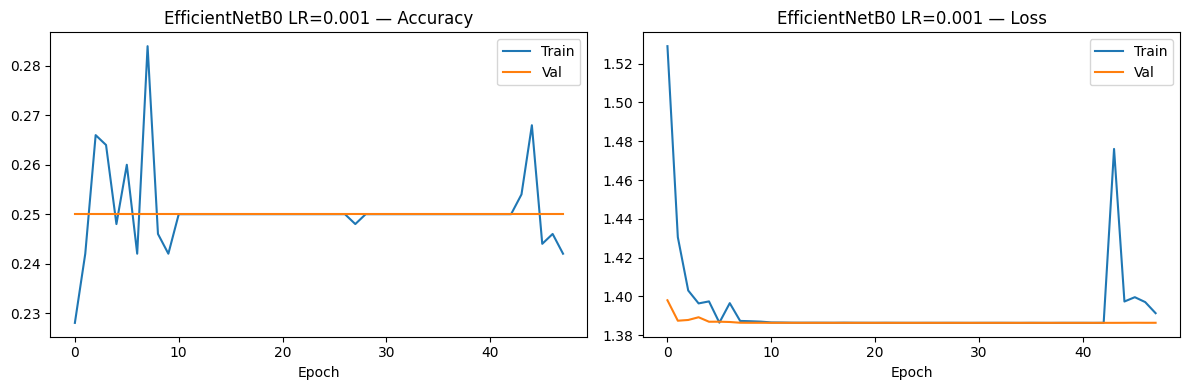


  Accuracy=0.2500  Precision=0.0625  Recall=0.2500  AUC=0.5000


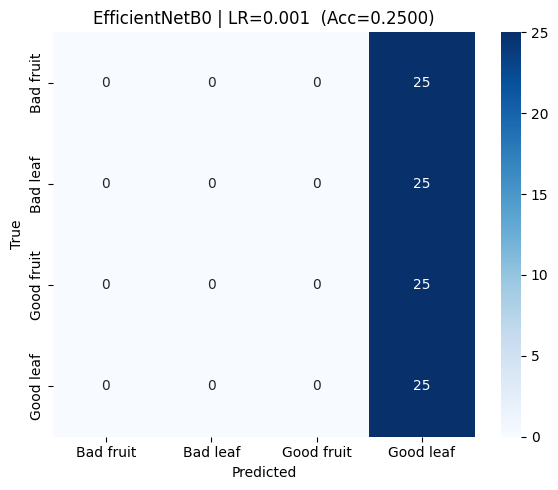


✅ All models trained!


In [25]:
all_results  = []
all_histories = {}

def plot_history(history, model_name, lr):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['accuracy'],     label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Val')
    axes[0].set_title(f'{model_name} LR={lr} — Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'], label='Val')
    axes[1].set_title(f'{model_name} LR={lr} — Loss')
    axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f'results/{model_name}_lr{lr}_history.png', dpi=150)
    plt.show()
    plt.close()

for model_name, builder in MODEL_BUILDERS.items():
    for lr in LEARNING_RATES:
        tf.keras.backend.clear_session()
        train_gen, val_gen, test_gen = get_generators()

        model, base = builder()
        model.compile(
            optimizer=optimizers.Adam(learning_rate=lr),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        callbacks = [
            EarlyStopping(monitor='val_loss', patience=PATIENCE,
                          restore_best_weights=True, verbose=1),
            ModelCheckpoint(
                filepath=f'results/{model_name}_lr{lr}_best.keras',
                monitor='val_accuracy', save_best_only=True, verbose=0),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
        ]

        print(f'\n{'='*60}')
        print(f'  Training {model_name}  |  LR = {lr}')
        print(f'{'='*60}')

        history = model.fit(
            train_gen, validation_data=val_gen,
            epochs=EPOCHS, callbacks=callbacks,
            class_weight=class_weights, verbose=1
        )

        # Fine-tune last layers at lr=0.001
        if base is not None and lr == 0.001:
            print(f'\n[Fine-tuning] Unfreezing last 30 layers of {model_name} ...')
            for layer in base.layers[-30:]:
                layer.trainable = True
            model.compile(
                optimizer=optimizers.Adam(learning_rate=lr / 10),
                loss='categorical_crossentropy', metrics=['accuracy']
            )
            history_ft = model.fit(
                train_gen, validation_data=val_gen,
                epochs=20, callbacks=callbacks,
                class_weight=class_weights, verbose=1
            )
            for k in history.history:
                history.history[k].extend(history_ft.history.get(k, []))

        plot_history(history, model_name, lr)
        all_histories[f'{model_name}_lr{lr}'] = history

        # ── Evaluate ──
        test_gen.reset()
        y_pred_probs = model.predict(test_gen, verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)
        y_true = test_gen.classes

        report    = classification_report(y_true, y_pred, output_dict=True,
                                          target_names=list(test_gen.class_indices.keys()))
        accuracy  = report['accuracy']
        precision = report['weighted avg']['precision']
        recall    = report['weighted avg']['recall']
        try:
            y_onehot = tf.keras.utils.to_categorical(y_true, NUM_CLASSES)
            auc = roc_auc_score(y_onehot, y_pred_probs, multi_class='ovr', average='macro')
        except Exception:
            auc = float('nan')

        print(f'\n  Accuracy={accuracy:.4f}  Precision={precision:.4f}  Recall={recall:.4f}  AUC={auc:.4f}')

        # Confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=list(test_gen.class_indices.keys()),
                    yticklabels=list(test_gen.class_indices.keys()))
        plt.title(f'{model_name} | LR={lr}  (Acc={accuracy:.4f})')
        plt.ylabel('True'); plt.xlabel('Predicted')
        plt.tight_layout()
        plt.savefig(f'results/{model_name}_lr{lr}_confusion.png', dpi=150)
        plt.show(); plt.close()

        all_results.append({
            'Model': model_name, 'LR': lr,
            'Accuracy': round(accuracy, 6), 'Precision': round(precision, 6),
            'Recall': round(recall, 6), 'AUC': round(auc, 6)
        })

print('\n✅ All models trained!')

##  Step 10 — Results Summary Table

In [26]:
df = pd.DataFrame(all_results).sort_values('Accuracy', ascending=False)
print(df.to_string(index=False))
df.to_csv('results/model_results.csv', index=False)
print('\nSaved to results/model_results.csv')

         Model    LR  Accuracy  Precision  Recall      AUC
   MobileNetV2 0.001      0.86   0.876190    0.86 0.980400
     CustomCNN 0.001      0.79   0.804061    0.79 0.922133
         VGG16 0.001      0.70   0.749084    0.70 0.897867
      ResNet50 0.001      0.50   0.560631    0.50 0.867867
EfficientNetB0 0.001      0.25   0.062500    0.25 0.500000

Saved to results/model_results.csv


##  Step 11 — Comparison Bar Chart

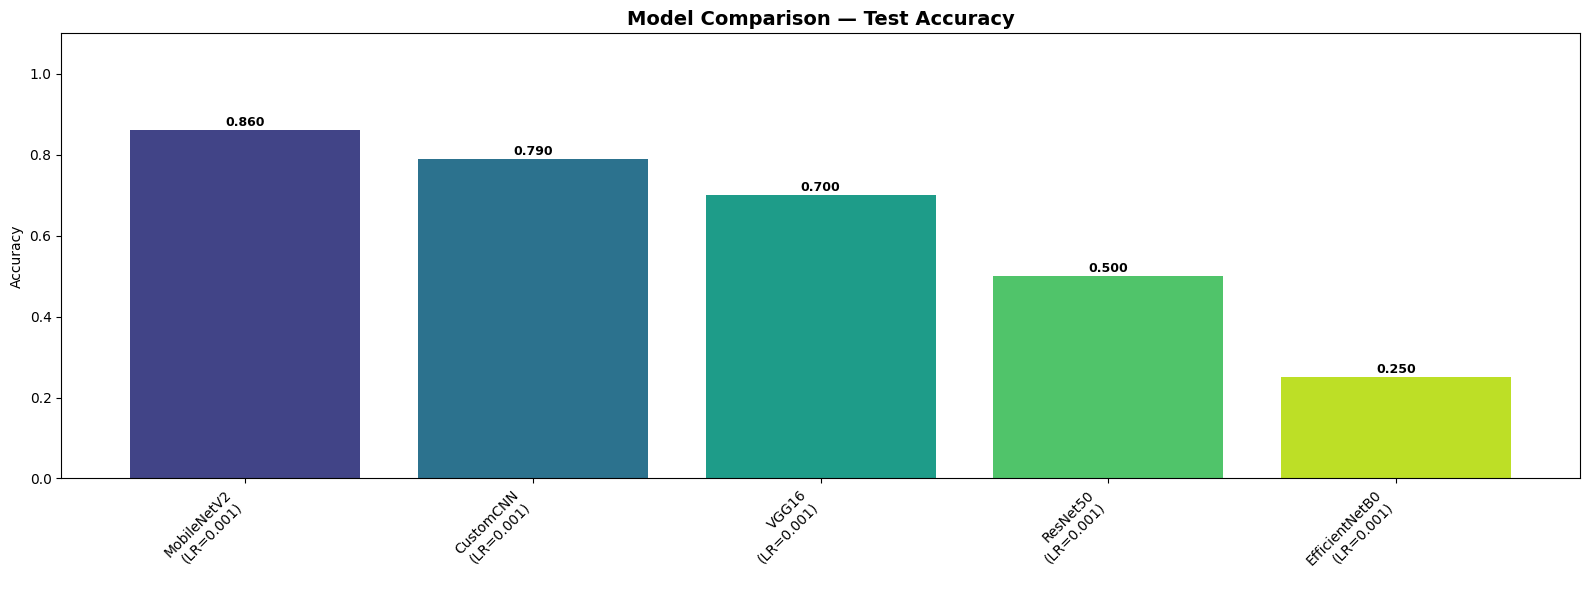

Chart saved to results/model_comparison.png


In [27]:
df_sorted = df.sort_values('Accuracy', ascending=False)
labels    = [f"{r['Model']}\n(LR={r['LR']})" for _, r in df_sorted.iterrows()]
accs      = df_sorted['Accuracy'].values

plt.figure(figsize=(16, 6))
bars = plt.bar(labels, accs,
               color=plt.cm.viridis(np.linspace(0.2, 0.9, len(labels))))
plt.ylim(0, 1.1)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', fontsize=9, fontweight='bold')
plt.title('Model Comparison — Test Accuracy', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy'); plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('results/model_comparison.png', dpi=150)
plt.show()
print('Chart saved to results/model_comparison.png')

##  Step 12 — Grad-CAM Visualization (Best Model)

In [28]:
# Load the best model checkpoint
best_row   = df.iloc[0]
best_model_name = best_row['Model']
best_lr    = best_row['LR']
best_path  = f'results/{best_model_name}_lr{best_lr}_best.keras'
print(f'Loading best model: {best_model_name} (LR={best_lr}) from {best_path}')

best_model = tf.keras.models.load_model(best_path)

# Grad-CAM helper
def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
        if hasattr(layer, 'layers'):   # nested model (transfer learning)
            for sub in reversed(layer.layers):
                if isinstance(sub, tf.keras.layers.Conv2D):
                    return sub.name
    return None

def grad_cam(model, img_array, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        pred_idx = tf.argmax(preds[0])
        class_ch = preds[:, pred_idx]
    grads = tape.gradient(class_ch, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_out[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_idx)

# Pick a sample test image
sample_class = os.listdir(TEST_DIR)[0]
sample_file  = os.listdir(os.path.join(TEST_DIR, sample_class))[0]
sample_path  = os.path.join(TEST_DIR, sample_class, sample_file)

img = tf.keras.preprocessing.image.load_img(sample_path, target_size=IMG_SIZE)
img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

last_conv = get_last_conv_layer(best_model)
print(f'Using conv layer: {last_conv}')

try:
    heatmap, pred_idx = grad_cam(best_model, img_array, last_conv)
    idx_to_class = {v: k for k, v in train_gen.class_indices.items()}
    predicted_class = idx_to_class.get(pred_idx, str(pred_idx))

    heatmap_rgb = plt.cm.jet(np.uint8(255 * heatmap))[:, :, :3]
    heatmap_rgb = tf.image.resize(heatmap_rgb, IMG_SIZE).numpy()
    overlay = np.clip(heatmap_rgb * 0.4 + img_array[0], 0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(img_array[0]);  axes[0].set_title(f'Original\n(True: {sample_class})'); axes[0].axis('off')
    axes[1].imshow(heatmap, cmap='jet'); axes[1].set_title('Grad-CAM Heatmap'); axes[1].axis('off')
    axes[2].imshow(overlay);        axes[2].set_title(f'Overlay\n(Pred: {predicted_class})'); axes[2].axis('off')
    plt.suptitle(f'Grad-CAM — {best_model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('results/gradcam.png', dpi=150)
    plt.show()
except Exception as e:
    print(f'Grad-CAM skipped: {e}')

Loading best model: MobileNetV2 (LR=0.001) from results/MobileNetV2_lr0.001_best.keras
Using conv layer: Conv_1
Grad-CAM skipped: No such layer: Conv_1. Existing layers are: ['mobilenetv2_1.00_224', 'global_average_pooling2d', 'dense', 'dropout', 'dense_1'].


##  Step 13 — Download All Results

In [ ]:
import shutil
shutil.make_archive('dragon_fruit_results', 'zip', 'results')

from google.colab import files
files.download('dragon_fruit_results.zip')
print('✅ Download started!')